In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
#Ler  base  de  dados
df= pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")

In [5]:
print(df.shape)

(500, 22)


In [6]:
print(df.head())

    farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
0  FARM0001  North India     Wheat            35.95     5.99          17.79   
1  FARM0002    South USA   Soybean            19.74     7.24          30.18   
2  FARM0003    South USA     Wheat            29.32     7.16          27.37   
3  FARM0004  Central USA     Maize            17.33     6.03          33.73   
4  FARM0005  Central USA    Cotton            19.37     5.92          33.86   

   rainfall_mm  humidity_%  sunlight_hours irrigation_type  ... sowing_date  \
0        75.62       77.03            7.27             NaN  ...  2024-01-08   
1        89.91       61.13            5.67       Sprinkler  ...  2024-02-04   
2       265.43       68.87            8.23            Drip  ...  2024-02-03   
3       212.01       70.46            5.03       Sprinkler  ...  2024-02-21   
4       269.09       55.73            7.93             NaN  ...  2024-02-05   

   harvest_date total_days yield_kg_per_hectare  s

In [7]:
#INFORMAÇÕES GERAIS
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

In [8]:
print("\nValores nulos:")


Valores nulos:


In [9]:
print(df.isnull().sum())


farm_id                   0
region                    0
crop_type                 0
soil_moisture_%           0
soil_pH                   0
temperature_C             0
rainfall_mm               0
humidity_%                0
sunlight_hours            0
irrigation_type         150
fertilizer_type           0
pesticide_usage_ml        0
sowing_date               0
harvest_date              0
total_days                0
yield_kg_per_hectare      0
sensor_id                 0
timestamp                 0
latitude                  0
longitude                 0
NDVI_index                0
crop_disease_status     130
dtype: int64


In [ ]:
#  TRATAMENTO DAS DATAS


df["sowing_date"] = pd.to_datetime(df["sowing_date"])
df["harvest_date"] = pd.to_datetime(df["harvest_date"])
df["timestamp"] = pd.to_datetime(df["timestamp"])


In [13]:
# Criando atributos derivados

df["sowing_month"] = df["sowing_date"].dt.month
df["harvest_month"] = df["harvest_date"].dt.month

In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   farm_id               500 non-null    object        
 1   region                500 non-null    object        
 2   crop_type             500 non-null    object        
 3   soil_moisture_%       500 non-null    float64       
 4   soil_pH               500 non-null    float64       
 5   temperature_C         500 non-null    float64       
 6   rainfall_mm           500 non-null    float64       
 7   humidity_%            500 non-null    float64       
 8   sunlight_hours        500 non-null    float64       
 9   irrigation_type       350 non-null    object        
 10  fertilizer_type       500 non-null    object        
 11  pesticide_usage_ml    500 non-null    float64       
 12  sowing_date           500 non-null    datetime64[ns]
 13  harvest_date        

In [ ]:
# REMOVENDO COLUNAS SEM VALOR PREDITIVO


df = df.drop(
    columns=[
        "farm_id",
        "sensor_id",
        "sowing_date",
        "harvest_date",
        "timestamp"
    ]
)


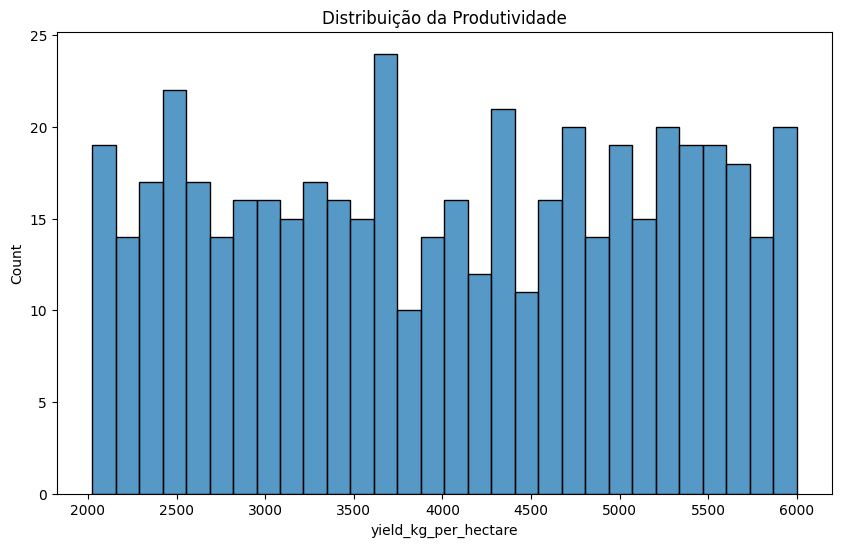

In [ ]:
#  ANÁLISE EXPLORATÓRIA


plt.figure(figsize=(10,6))
sns.histplot(df["yield_kg_per_hectare"], bins=30)
plt.title("Distribuição da Produtividade")
plt.show()


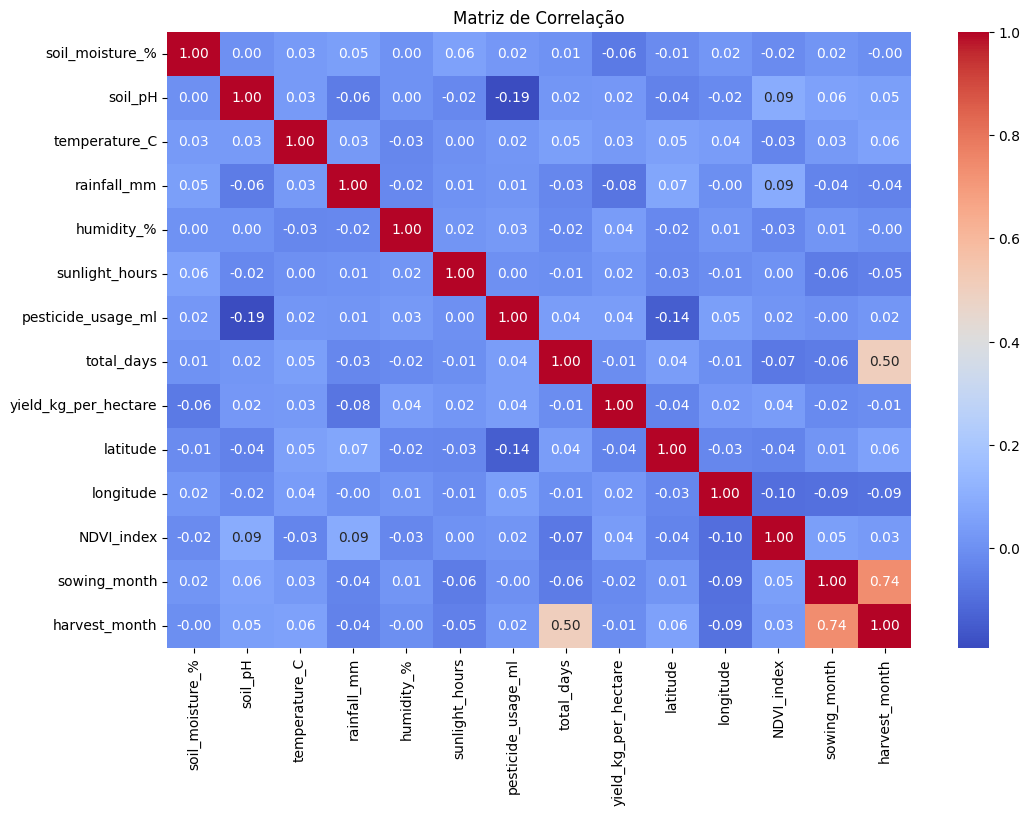

In [ ]:
#  CORRELAÇÃO


numericas = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numericas.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de Correlação")
plt.show()


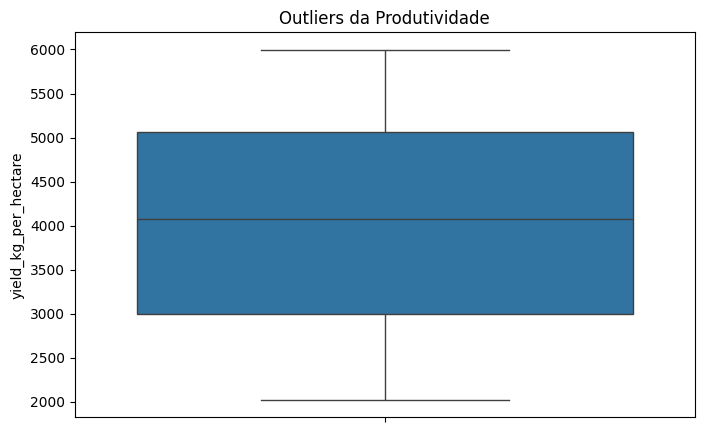

In [ ]:
#  BOXPLOT PRODUTIVIDADE

plt.figure(figsize=(8,5))
sns.boxplot(y=df["yield_kg_per_hectare"])
plt.title("Outliers da Produtividade")
plt.show()


In [ ]:
#  DEFININDO TARGET


X = df.drop("yield_kg_per_hectare", axis=1)
y = df["yield_kg_per_hectare"]

In [ ]:
# IDENTIFICANDO TIPOS


categoricas = X.select_dtypes(include="object").columns
numericas = X.select_dtypes(exclude="object").columns

In [ ]:
#  PIPELINE DE TRATAMENTO


num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numericas),
        ("cat", cat_transformer, categoricas)
    ]
)

In [ ]:
#  MODELO ÁRVORE DE DECISÃO


modelo = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=20,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", modelo)
    ]
)

In [ ]:
# TREINO E TESTE


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm',
       'humidity_%', 'sunlight_hours', 'pesticide_usage_ml', 'total_days',
       'latitude', 'longitude', 'NDVI_index', 'sowing_month', 'harvest_month'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['region', 'crop_type', 'irrigation_type', 'fertilizer_type',
       'crop_disease_status'],
      dtype='object'))])),
                ('modelo',
                 DecisionTreeRegressor(max_depth=6, min_samples_split=20,
                                       random_state=42))])

In [ ]:
#  PREVISÕES


y_pred = pipeline.predict(X_test)

In [ ]:
#  MÉTRICAS


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\nRESULTADOS")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


RESULTADOS
MAE : 1175.68
RMSE: 1411.68
R²  : -0.4430


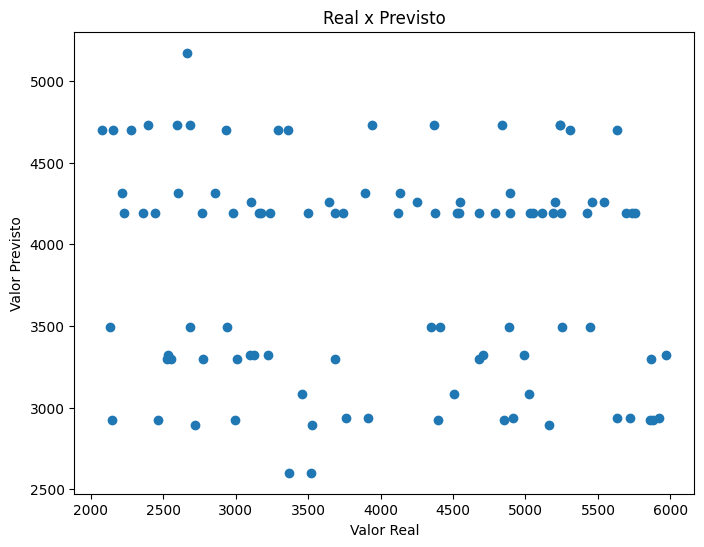

In [ ]:
#  REAL X PREVISTO


resultado = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

plt.figure(figsize=(8,6))
plt.scatter(resultado["Real"], resultado["Previsto"])
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real x Previsto")
plt.show()


              Variavel  Importancia
6   pesticide_usage_ml     0.201454
5       sunlight_hours     0.174825
9            longitude     0.161452
10          NDVI_index     0.092229
3          rainfall_mm     0.088509
0      soil_moisture_%     0.087074
8             latitude     0.071915
2        temperature_C     0.062444
7           total_days     0.060098
1              soil_pH     0.000000
4           humidity_%     0.000000
11        sowing_month     0.000000
12       harvest_month     0.000000
13  region_Central USA     0.000000
14  region_East Africa     0.000000


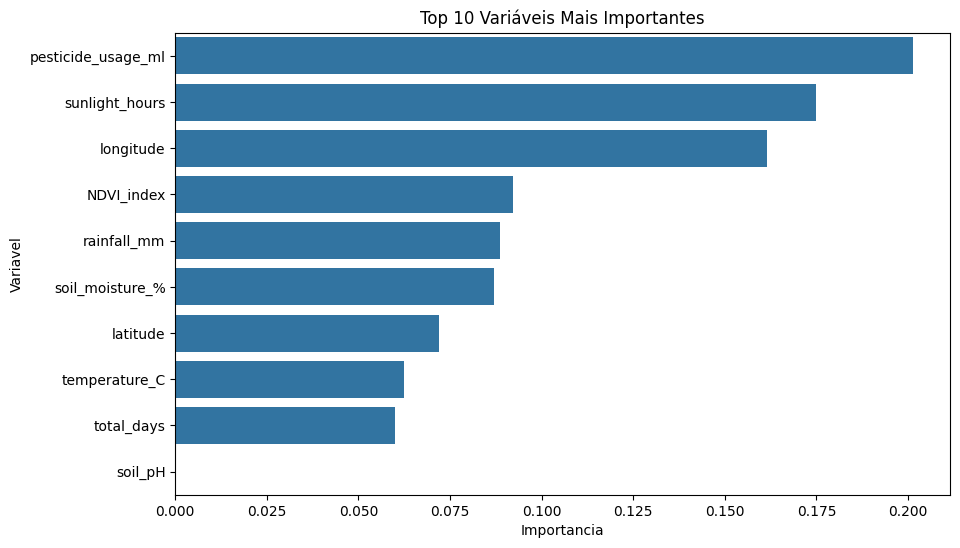

In [ ]:
#  IMPORTÂNCIA DAS VARIÁVEIS


feature_names = (
    numericas.tolist() +
    list(
        pipeline.named_steps["preprocessamento"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categoricas)
    )
)

importancias = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": pipeline.named_steps["modelo"].feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print(importancias.head(15))

plt.figure(figsize=(10,6))
sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variavel"
)
plt.title("Top 10 Variáveis Mais Importantes")
plt.show()

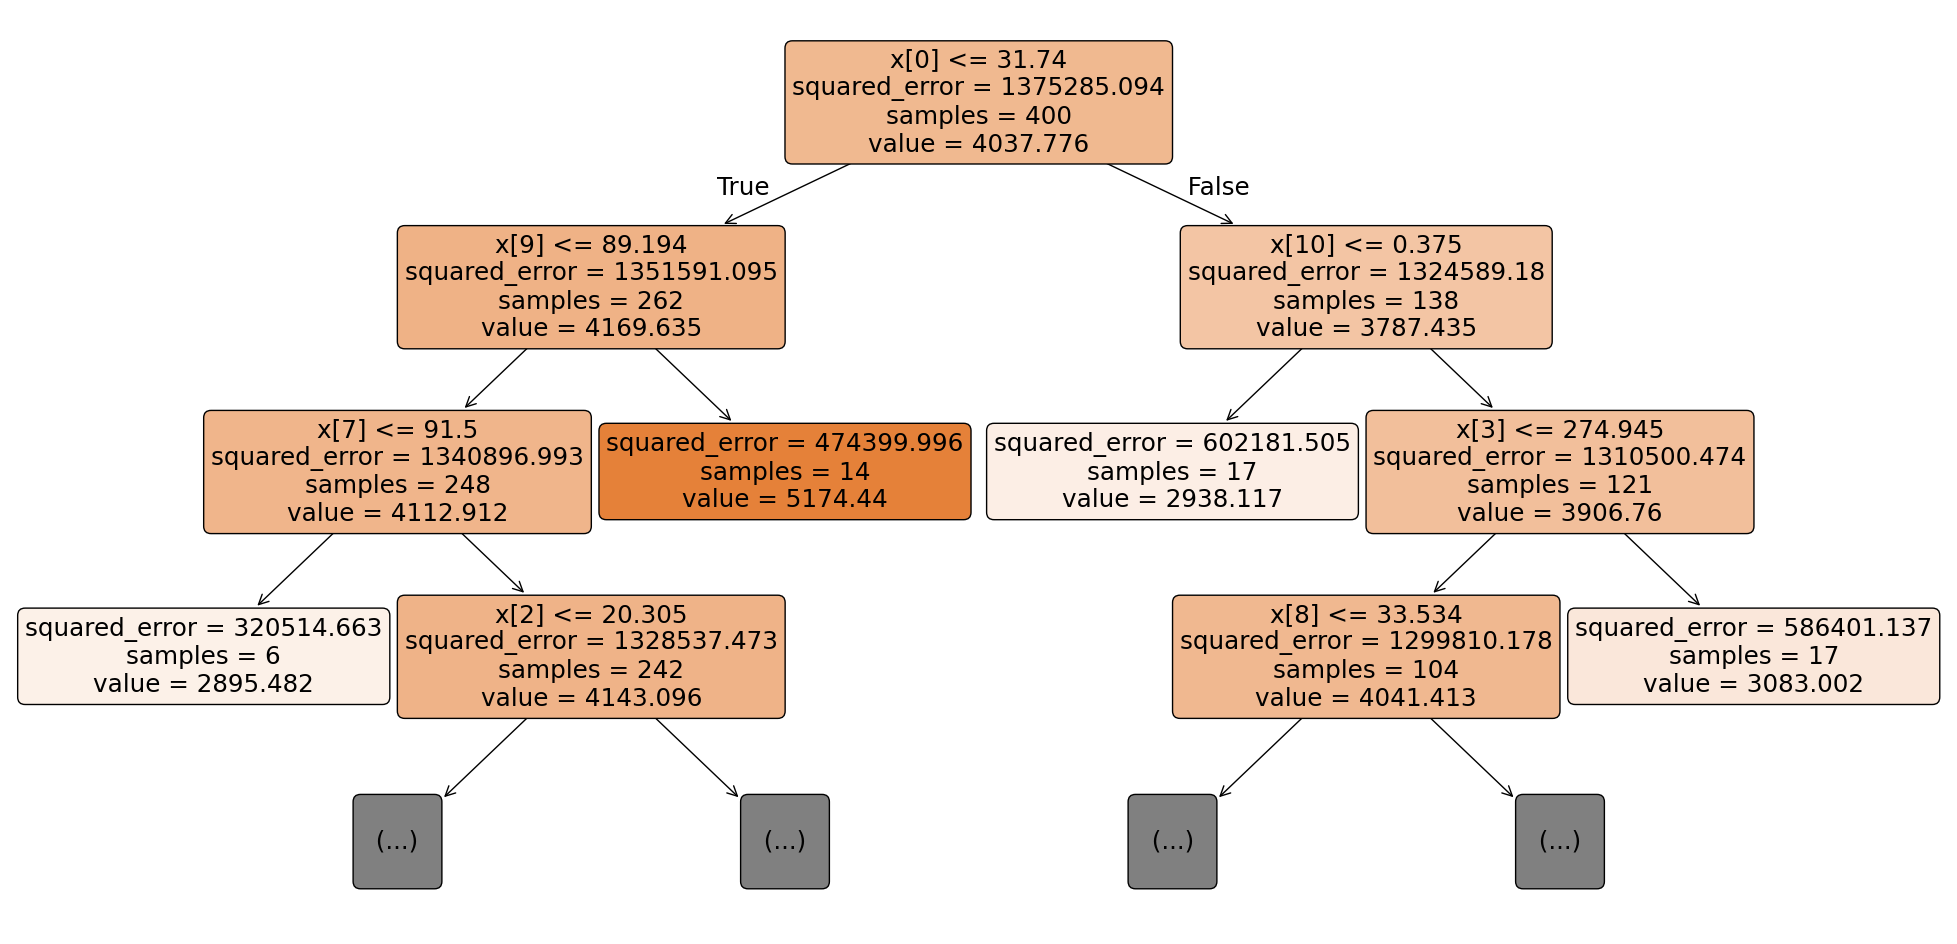

In [ ]:
#  VISUALIZAÇÃO DA ÁRVORE


plt.figure(figsize=(25,12))

plot_tree(
    pipeline.named_steps["modelo"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()